In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 

In [2]:
divar_full_df = pd.read_csv('Divar.csv')

C:\Users\HAMTA\AppData\Local\Temp\ipykernel_12808\3866395334.py:1: DtypeWarning: Columns (11,27,29,53) have mixed types. Specify dtype option on import or set low_memory=False.
  divar_full_df = pd.read_csv('Divar.csv')


In [87]:
#dar tabdile magadire gimat, rahn va ejare be moshkel khordam va movagatan ba data haye furush pish raftam
df_sale = divar_full_df[divar_full_df['price_value'].notnull()].copy()

#inja magadire part ro say kardam hazf konam
df_sale = df_sale[df_sale['price_value']>50000000]
df_sale = df_sale[df_sale['price_value']<100000000000]

#feature hayi ke felan be nazar mohem hastand ro entekhab kardam
needed_columns = ['city_slug','price_value','building_size'
                  ,'floor','rooms_count','has_elevator','has_warehouse'
                  ,'has_parking','is_rebuilt','cat3_slug','location_latitude',
                  'location_longitude', 'has_balcony','has_barbecue','has_pool',
                  'has_jacuzzi','has_sauna','has_security_guard']


In [88]:
#inja chon sale sakht be farsi bud tabdilesh kardam be int
def fa_to_en(text):
    mapping = {'۰':'0','۱':'1','۲':'2','۳':'3','۴':'4','۵':'5','۶':'6','۷':'7','۸':'8','۹':'9'}
    return ''.join([mapping.get(ch, ch) for ch in str(text)])

def clean_year(val):
    val = fa_to_en(str(val)).strip()
    if 'قبل' in val:
        return 1365
    if val.isdigit():
        return int(val)

df_sale['construction_year'] = df_sale['construction_year'].apply(clean_year)
#sale sakht ro be senne bana taghir dadam
df_sale['building_age'] = 1404 - df_sale['construction_year']
needed_columns.append('building_age')

In [89]:
df_sale = df_sale.drop(columns = 'construction_year')

In [90]:
df_sale = df_sale[needed_columns]

In [91]:
#az datasete shahrha ro ezafe kardam be datasete asli
df_classification = pd.read_csv('iran_city_classification.csv')
df_classification.rename(columns={'نام شهر':'city_slug'}, inplace=True)
df_sale = df_sale.merge(df_classification, on='city_slug', how='left')

In [92]:
#shahr haye bozorgo kuchik ro binary kardam
df_sale['is_big_city'] = df_sale['دسته‌بندی'].map({'کلان‌شهر':1,
                                                   'شهر کوچک': 0})
drop_columns = ["city_slug",'دسته‌بندی']
df_sale = df_sale.drop(columns=drop_columns)


In [93]:
#roomcount ro be int tabdil kardam
rooms_map = {
    'بدون اتاق':0,
    'یک': 1,
    'دو': 2,
    'سه': 3,
    'چهار': 4,
    'پنج یا بیشتر':5
}

df_sale['rooms_count'] = df_sale['rooms_count'].map(rooms_map)

In [94]:
#magadire floor ro dorost kardam 
def clean_floor(val):
    try:
        return int(float(val))
    except:
        return None 
    
df_sale['floor'] = df_sale['floor'].apply(clean_floor)

In [95]:
#in emkanat to binary kardam
bool_columns = ['has_elevator','has_warehouse','has_parking','is_rebuilt',
                 'has_balcony','has_barbecue','has_pool',
                  'has_jacuzzi','has_sauna','has_security_guard']

for columns in bool_columns:
    df_sale[columns] = df_sale[columns].map({ True: 1, False: 0})

In [96]:
#daste bandi noe agahi tu gimat tassir dare. baraye hamin ba one-hot encoding saay kardam ke tu predict tasiresh bedam


df_sale = pd.get_dummies(df_sale, columns=['cat3_slug'], drop_first=True)
df_sale

,price_value,building_size,floor,rooms_count,has_elevator,has_warehouse,has_parking,is_rebuilt,location_latitude,location_longitude,...,cat3_slug_house-villa-sell,cat3_slug_industry-agriculture-business-rent,cat3_slug_industry-agriculture-business-sell,cat3_slug_office-rent,cat3_slug_office-sell,cat3_slug_partnership,cat3_slug_plot-old,cat3_slug_presell,cat3_slug_shop-rent,cat3_slug_shop-sell
0,8.500000e+09,60.0,3.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,...,False,False,False,False,False,False,False,False,False,False
1,5.750000e+09,115.0,4.0,2.0,1.0,1.0,1.0,NaN,NaN,NaN,...,False,False,False,False,False,False,False,False,False,False
2,8.700000e+09,100.0,4.0,2.0,1.0,1.0,1.0,NaN,35.729832,51.505466,...,False,False,False,False,False,False,False,False,False,False
3,6.500000e+08,78.0,4.0,2.0,1.0,1.0,1.0,1.0,35.712364,50.794781,...,False,False,False,False,False,False,False,False,False,False
4,3.000000e+09,80.0,3.0,2.0,0.0,0.0,1.0,0.0,NaN,NaN,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
547389,4.000000e+09,140.0,1.0,2.0,1.0,1.0,1.0,NaN,37.505325,45.050369,...,False,False,False,False,False,False,False,False,False,False
547390,3.600000e+09,91.0,4.0,2.0,0.0,1.0,1.0,1.0,35.652096,51.323963,...,False,False,False,False,False,False,False,False,False,False
547391,4.350000e+09,105.0,2.0,2.0,1.0,1.0,1.0,0.0,NaN,NaN,...,False,False,False,False,False,False,False,False,False,False
547392,7.470000e+09,180.0,4.0,4.0,1.0,1.0,1.0,NaN,34.350235,47.083241,...,False,False,False,False,False,False,False,False,False,False


In [97]:

#magadire gom shode ro check kardam
df_sale.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 547394 entries, 0 to 547393
Data columns (total 29 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   price_value                                   547394 non-null  float64
 1   building_size                                 546153 non-null  float64
 2   floor                                         299748 non-null  float64
 3   rooms_count                                   439185 non-null  float64
 4   has_elevator                                  300155 non-null  float64
 5   has_warehouse                                 414510 non-null  float64
 6   has_parking                                   414510 non-null  float64
 7   is_rebuilt                                    302825 non-null  float64
 8   location_latitude                             359119 non-null  float64
 9   location_longitude                            35

In [98]:
#age megdari dade nashode bashe pas ehtemalan jadid bude. pas be surate pishfarz bazsazi shode dar nazar gereftam
df_sale['is_rebuilt'] = df_sale['is_rebuilt'].fillna(1)

basic_needs = ['has_elevator','has_warehouse','has_parking']
#inja az miane baraye por kardane magadir estefade kardam
for column in basic_needs:
    df_sale[column] = df_sale[column].fillna(df_sale[column].median())
#3ta feature ro jam kardam. chon tagriban be yek andaze moheman
df_sale['feature_count'] = df_sale['has_elevator'] + df_sale['has_parking'] + df_sale['has_warehouse']


In [99]:
df_sale = df_sale.drop(columns = basic_needs)

In [100]:
#hamun kar ro baraye feature hayi ke luxury tar hastand tekrar kardam
luxury_needs = ['has_balcony','has_barbecue','has_pool',
                  'has_jacuzzi','has_sauna','has_security_guard']

for column in luxury_needs:
    df_sale[column] = df_sale[column].fillna(df_sale[column].median())

df_sale['feature_count_2'] = df_sale['has_balcony'] + df_sale['has_barbecue'] + df_sale['has_pool'] + df_sale['has_jacuzzi'] + df_sale['has_sauna'] + df_sale['has_balcony']

In [101]:
df_sale = df_sale.drop(columns = luxury_needs)

In [102]:
df_sale['log_price'] = np.log1p(df_sale['price_value'])

In [103]:
#magadire gomshode ro por kardam
df_sale['building_size'] = df_sale['building_size'].fillna(df_sale['building_size'].median())
df_sale['floor'] = df_sale['floor'].fillna(0)
df_sale['rooms_count'] = df_sale['rooms_count'].fillna(0)
df_sale['building_age'] = df_sale['building_age'].fillna(0)
df_sale['is_big_city'] = df_sale['is_big_city'].fillna(df_sale['is_big_city'].median())
df_sale['location_latitude'] = df_sale['location_latitude'].fillna(df_sale['location_latitude'].mean())
df_sale['location_longitude'] = df_sale['location_longitude'].fillna(df_sale['location_longitude'].mean())


In [ ]:
# amele data leakage boodan pas hazf kardam:
#df_sale['price_per_sqm'] = df_sale['price_value'] / df_sale['building_size']
#df_sale['log_price_sqm'] = np.log1p(df_sale['price_per_sqm'])

In [105]:
#baraye inke model behtar tashkhis bede senne bana ro dastebandi kardam
df_sale['age_group'] = pd.cut(df_sale['building_age'],
                         bins=[-1, 3, 10, 25, 100],
                         labels=[1, 2, 3, 4])

In [106]:
df_sale.info()
df_sale = df_sale.drop(columns = 'price_value')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 547394 entries, 0 to 547393
Data columns (total 24 columns):
 #   Column                                        Non-Null Count   Dtype   
---  ------                                        --------------   -----   
 0   price_value                                   547394 non-null  float64 
 1   building_size                                 547394 non-null  float64 
 2   floor                                         547394 non-null  float64 
 3   rooms_count                                   547394 non-null  float64 
 4   is_rebuilt                                    547394 non-null  float64 
 5   location_latitude                             547394 non-null  float64 
 6   location_longitude                            547394 non-null  float64 
 7   building_age                                  547394 non-null  float64 
 8   is_big_city                                   547394 non-null  float64 
 9   cat3_slug_apartment-sell             

In [107]:
x = df_sale.drop(columns='log_price')
y = df_sale['log_price']

In [108]:
from sklearn.model_selection import train_test_split

x_temp, x_test, y_temp, y_test = train_test_split(x,y, test_size=0.2, random_state= 42)

x_train, x_val, y_train, y_val = train_test_split(x_temp, y_temp, test_size=0.25, random_state=42)

In [109]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_val_scaled = scaler.transform(x_val)
x_test_scaled = scaler.transform(x_test)

In [110]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x_train_scaled, y_train)

LinearRegression()

In [111]:
y_pred_val = model.predict(x_val_scaled)

In [112]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_val, y_pred_val)
mse = mean_squared_error(y_val, y_pred_val)
r2 = r2_score(y_val, y_pred_val)

In [113]:
print(f"linear regression mse:{mse}")

linear regression mse:0.8478183997478006


In [114]:
print(f"linear regression mae: {mae}" )

linear regression mae: 0.6695832065594955


In [115]:
print(f"linear regression R2: {r2}")

linear regression R2: 0.31400687761923407


In [116]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(n_estimators=800,
    learning_rate=0.025,
    max_depth=8,
    subsample=0.9,
    colsample_bytree=0.9,
    gamma=0.05,
    reg_alpha=0.1,
    reg_lambda=2.0,
    tree_method='hist',
    random_state=42,
    enable_categorical = True)

xgb_model.fit(x_train, y_train)
y_pred_xgb = xgb_model.predict(x_val)


In [117]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

r2_xgb = r2_score(y_val, y_pred_xgb)
mae_xgb = mean_absolute_error(y_val, y_pred_xgb)
mse_xgb = mean_squared_error(y_val, y_pred_xgb)

print (f"XGBoost R2: {r2_xgb}")

XGBoost R2: 0.5527492779084495


In [118]:
print(f"XGBoost mae: {mae_xgb}")

XGBoost mae: 0.4862177710546956


In [119]:
print(f"XGBoost mse: {mse_xgb}")

XGBoost mse: 0.5527568413131052


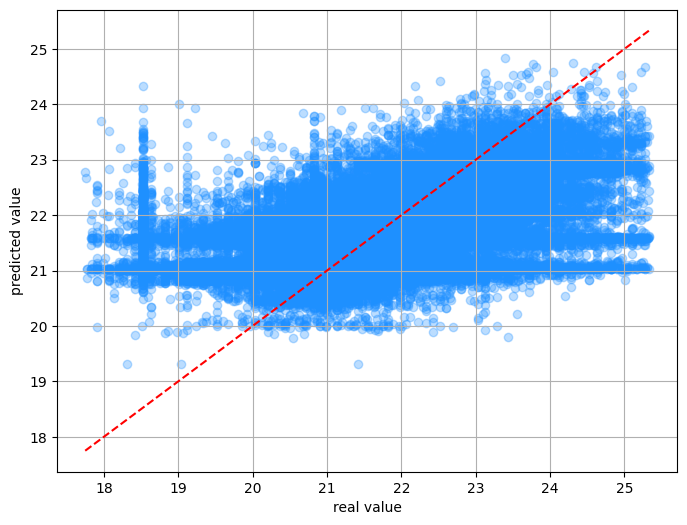

In [ ]:
#Real/predicted values comparison (linear regression)
plt.figure(figsize=(8, 6))
plt.scatter(y_val, y_pred_val, alpha=0.3, color='dodgerblue')
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
plt.xlabel("real value")
plt.ylabel("predicted value")
plt.grid(True)
plt.show()

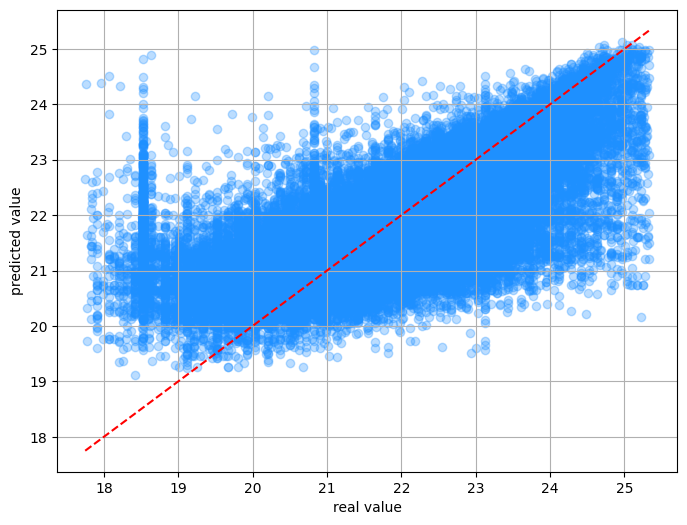

In [ ]:
#Real/predicted values comparison (XGboost)
plt.figure(figsize=(8, 6))
plt.scatter(y_val, y_pred_xgb, alpha=0.3, color='dodgerblue')
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
plt.xlabel("real value")
plt.ylabel("predicted value")
plt.grid(True)
plt.show()

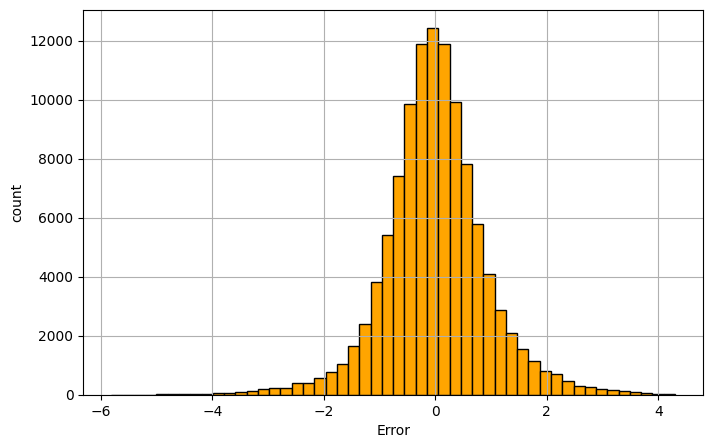

In [ ]:
#Model Error graph (linear regression)
residuals = y_val - y_pred_val

plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=50, color='orange', edgecolor='black')
plt.xlabel("Error")
plt.ylabel("count")
plt.grid(True)
plt.show()

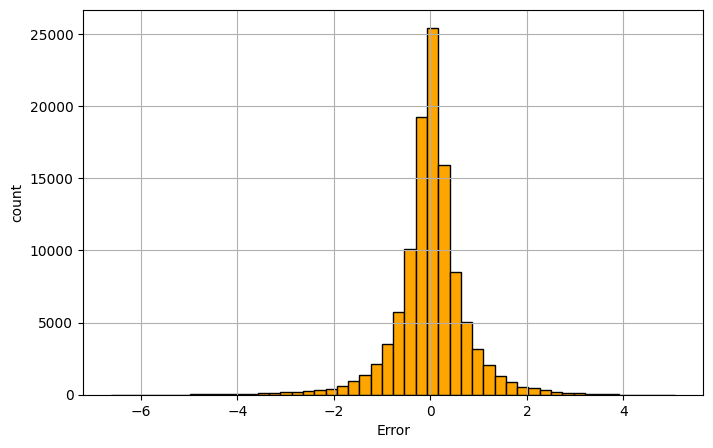

In [ ]:
#Model Error graph (XGboost)
residuals = y_val - y_pred_xgb

plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=50, color='orange', edgecolor='black')
plt.xlabel("Error")
plt.ylabel("count")
plt.grid(True)
plt.show()

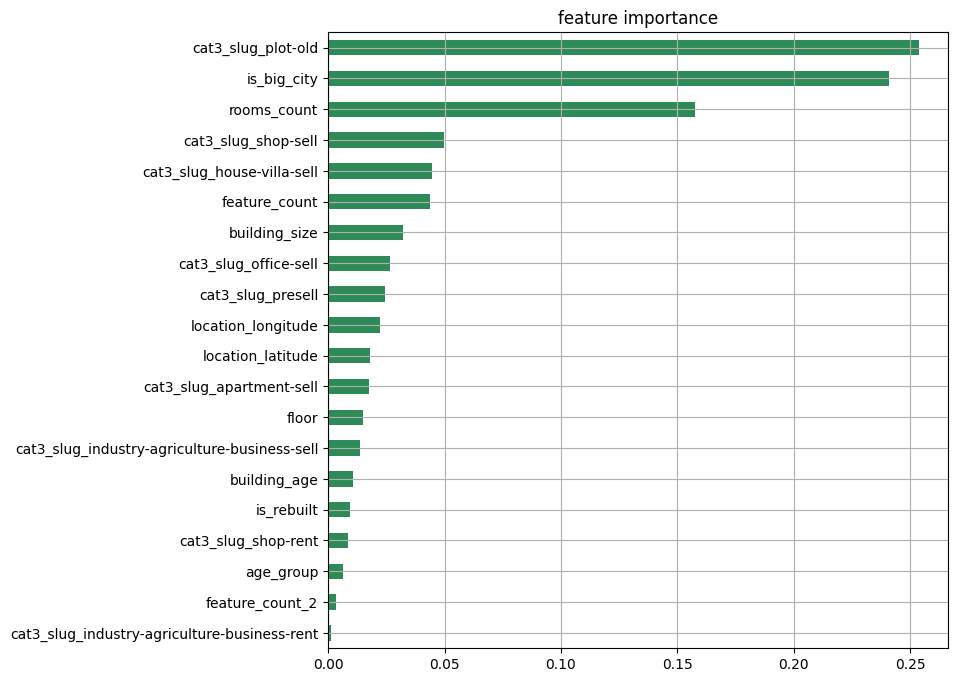

In [ ]:
#Feature importance (xgboost)
importances = xgb_model.feature_importances_
feat_names = x.columns

importance_df = pd.Series(importances, index=feat_names).sort_values(ascending=True)

plt.figure(figsize=(8, 8))
importance_df.tail(20).plot(kind='barh', color='seagreen')
plt.title("feature importance")
plt.grid(True)
plt.show()